# [STARTER] Udaplay Project

## Part 02 - Agent

In this part of the project, you'll use your VectorDB to be part of your Agent as a tool.

You're building UdaPlay, an AI Research Agent for the video game industry. The agent will:
1. Answer questions using internal knowledge (RAG)
2. Search the web when needed
3. Maintain conversation state
4. Return structured outputs
5. Store useful information for future use

### Setup

In [1]:
# Only needed for Udacity workspace

import importlib.util
import sys

# Check if 'pysqlite3' is available before importing
if importlib.util.find_spec("pysqlite3") is not None:
    import pysqlite3
    sys.modules['sqlite3'] = sys.modules.pop('pysqlite3')

In [2]:
import os
from typing import Dict, List

import chromadb
from chromadb.utils import embedding_functions
from pydantic import BaseModel, Field
from tavily import TavilyClient

from lib.agents import Agent
from lib.llm import LLM
from lib.messages import SystemMessage, UserMessage
from lib.parsers import PydanticOutputParser
from lib.tooling import tool

In [3]:
import os
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv(), override=True)
assert os.getenv("OPENAI_API_KEY"), "OPENAI_API_KEY is not set"
assert os.getenv("OPENAI_BASE_URL"), "OPENAI_BASE_URL is not set"
assert os.getenv("TAVILY_API_KEY"), "TAVILY_API_KEY is not set"

In [4]:
# Environment variables are loaded in the setup cell above.
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
MODEL_NAME = "gpt-4o-mini"

### Tools

Build at least 3 tools:
- retrieve_game: To search the vector DB
- evaluate_retrieval: To assess the retrieval performance
- game_web_search: If no good, search the web


#### Retrieve Game Tool

In [5]:
# Same path, collection name and embedding function as Part 1
chroma_client = chromadb.PersistentClient(path="chromadb")
embedding_fn = embedding_functions.OpenAIEmbeddingFunction(
    api_key_env_var="OPENAI_API_KEY",
    api_base=os.getenv("OPENAI_BASE_URL"),
    model_name="text-embedding-3-small",
)
collection = chroma_client.get_collection(name="udaplay", embedding_function=embedding_fn)


@tool
def retrieve_game(query: str) -> List[Dict]:
    """
    Semantic search: Finds most results in the vector DB
    args:
    - query: a question about game industry.

    You'll receive results as list. Each element contains:
    - Platform: like Game Boy, PlayStation 5, Xbox 360...
    - Name: Name of the Game
    - YearOfRelease: Year when that game was released for that platform
    - Description: Additional details about the game
    """
    results = collection.query(query_texts=[query], n_results=3)
    return [
        {
            "Platform": meta["Platform"],
            "Name": meta["Name"],
            "YearOfRelease": meta["YearOfRelease"],
            "Description": meta["Description"],
            "distance": round(dist, 3),
        }
        for meta, dist in zip(results["metadatas"][0], results["distances"][0])
    ]

#### Evaluate Retrieval Tool

In [6]:
class EvaluationReport(BaseModel):
    useful: bool = Field(description="Whether the documents are enough to answer the question")
    description: str = Field(description="Detailed explanation of the evaluation")
    confidence: float = Field(ge=0.0, le=1.0, description="Confidence between 0 and 1")


@tool
def evaluate_retrieval(question: str, retrieved_docs: List[Dict]) -> Dict:
    """
    Based on the user's question and on the list of retrieved documents,
    it will analyze the usability of the documents to respond to that question.
    args:
    - question: original question from user
    - retrieved_docs: retrieved documents most similar to the user query in the Vector Database
    The result includes:
    - useful: whether the documents are useful to answer the question
    - description: description about the evaluation result
    - confidence: confidence from 0 to 1 in that evaluation
    """
    judge = LLM(model=MODEL_NAME, temperature=0.0)
    messages = [
        SystemMessage(content=(
            "Your task is to evaluate if the documents are enough to respond the query. "
            "Give a detailed explanation, so it's possible to take an action to accept it or not. "
            "Documents must cover the exact game AND the exact platform asked about; "
            "otherwise they are not useful."
        )),
        UserMessage(content=f"Question: {question}\n\nDocuments:\n{json.dumps(retrieved_docs, indent=2)}"),
    ]
    response = judge.invoke(messages, response_format=EvaluationReport)
    return PydanticOutputParser(model_class=EvaluationReport).parse(response).model_dump()

#### Game Web Search Tool

In [7]:
tavily_client = TavilyClient(api_key=TAVILY_API_KEY)


@tool
def game_web_search(question: str) -> List[Dict]:
    """
    Web search: searches the web with Tavily when the vector DB results aren't good enough
    args:
    - question: a question about game industry.

    Returns the search results, including each page's URL, so the answer can cite its source.
    """
    response = tavily_client.search(question, topic="general", max_results=3)
    return [
        {"title": r["title"], "url": r["url"], "content": r["content"]}
        for r in response["results"]
    ]

### Agent

In [8]:
INSTRUCTIONS = """You are UdaPlay, an AI research assistant for the video game industry.

For every question follow this process:
1. Call retrieve_game to search the internal vector database.
2. Call evaluate_retrieval with the original question and the retrieved documents.
3. If the evaluation says the documents are useful, answer from them and cite "internal database".
4. If not useful, call game_web_search and answer from those results, citing each source URL.
5. If neither source answers the question, say so honestly instead of guessing.

Be concise. End every answer with a "Sources:" line, and mention which tool(s) you used.
The agent remembers earlier turns of the conversation, so use them for follow-up questions."""

import json

agent = Agent(
    model_name=MODEL_NAME,
    instructions=INSTRUCTIONS,
    tools=[retrieve_game, evaluate_retrieval, game_web_search],
    temperature=0.0,
)


def ask(question: str, session_id: str = "demo"):
    run = agent.invoke(question, session_id=session_id)
    messages = run.get_final_state()["messages"]
    # Show the steps of this turn only (after the last user message)
    last_user = max(i for i, m in enumerate(messages) if m.role == "user")
    print(f"Q: {question}\n")
    for m in messages[last_user + 1:]:
        if m.role == "assistant" and m.tool_calls:
            for call in m.tool_calls:
                print(f"  -> tool call: {call.function.name}({call.function.arguments[:120]})")
        elif m.role == "tool":
            print(f"  <- {m.name} result: {m.content[:200]}...")
    print(f"\nA: {messages[-1].content}\n" + "=" * 80)

In [9]:
ask("When was Pokémon Gold and Silver released?")
ask("Which one was the first 3D platformer Mario game?")
ask("Was Mortal Kombat X released for PlayStation 5?")
ask("And what year did the first one come out?")  # follow-up: relies on conversation memory

[StateMachine] Starting: __entry__
[StateMachine] Executing step: message_prep


[StateMachine] Executing step: llm_processor


[StateMachine] Executing step: tool_executor


[StateMachine] Executing step: llm_processor


[StateMachine] Executing step: tool_executor


...

[StateMachine] Executing step: llm_processor


[StateMachine] Executing step: tool_executor


[StateMachine] Executing step: llm_processor


[StateMachine] Executing step: tool_executor


[StateMachine] Executing step: llm_processor
[StateMachine] Terminating: __termination__
Q: And what year did the first one come out?

  -> tool call: retrieve_game({"query":"Mortal Kombat first game release year"})
  <- retrieve_game result: "[{'Platform': 'GameCube', 'Name': 'Super Smash Bros. Melee', 'YearOfRelease': 2001, 'Description': 'A crossover fighting game featuring characters from various Nintendo franchises battling it out in ...
  -> tool call: evaluate_retrieval({"question":"And what year did the first Mortal Kombat come out?","retrieved_docs":[{"Platform":"GameCube","Name":"Super)
  <- evaluate_retrieval result: "{'useful': False, 'description': \"The documents provided do not contain any information about the game 'Mortal Kombat' or its release year. They only include details about other games such as 'Super...
  -> tool call: game_web_search({"question":"Mortal Kombat first game release year"})
  <- game_web_search result: "[{'title': 'Mortal Kombat - Wikipedia', 'url

#### Richer queries with the personalised dataset
The `games/` folder now holds 25 titles (10 added: Zelda, Halo, Minecraft, Witcher 3, Celeste, God of War, Hades, Animal Crossing, Elden Ring, Baldur's Gate 3). These questions are answered from the vector DB, including genre-style queries that don't name the game.

In [10]:
ask("Which roguelike game was released on PC in 2020, and who made it?")
ask("What Nintendo Switch games do you have in the database?")
ask("Which open-world action RPG came out for PlayStation 5?")


[StateMachine] Starting: __entry__
[StateMachine] Executing step: message_prep


[StateMachine] Executing step: llm_processor


[StateMachine] Executing step: tool_executor


[StateMachine] Executing step: llm_processor


[StateMachine] Executing step: tool_executor


...

[StateMachine] Executing step: llm_processor


[StateMachine] Executing step: tool_executor


[StateMachine] Executing step: llm_processor


[StateMachine] Executing step: tool_executor


[StateMachine] Executing step: llm_processor
[StateMachine] Terminating: __termination__
Q: Which open-world action RPG came out for PlayStation 5?

  -> tool call: retrieve_game({"query":"open-world action RPG PlayStation 5"})
  <- retrieve_game result: "[{'Platform': 'PlayStation 5', 'Name': 'Elden Ring', 'YearOfRelease': 2022, 'Description': 'An open-world action RPG created with George R. R. Martin, set in the Lands Between.', 'distance': 0.327}, ...
  -> tool call: evaluate_retrieval({"question":"Which open-world action RPG came out for PlayStation 5?","retrieved_docs":[{"Platform":"PlayStation 5","Nam)
  <- evaluate_retrieval result: "{'useful': True, 'description': \"The documents provided include information about two games that were released for the PlayStation 5: 'Elden Ring' and 'Marvel's Spider-Man 2'. Among these, 'Elden Ri...

A: The open-world action RPG that came out for PlayStation 5 is Elden Ring, released in 2022. 

Sources: internal database.


### (Optional) Advanced — Stand Out

In [11]:
from lib.memory import LongTermMemory, MemoryFragment
from lib.vector_db import VectorStoreManager

# Persistent store, kept separate from the "udaplay" game collection
memory_db = VectorStoreManager(OPENAI_API_KEY, persist_path="chromadb_memory")
long_term_memory = LongTermMemory(memory_db)
MEMORY_OWNER = "default_user"


@tool
def search_memory(query: str) -> List[str]:
    """
    Long-term memory: searches facts the agent learned in earlier conversations.
    args:
    - query: the topic or question to look up.

    Returns a list of previously saved facts (empty if nothing relevant is stored).
    """
    result = long_term_memory.search(query, owner=MEMORY_OWNER, limit=3)
    return [
        f"{frag.content} (distance {dist:.2f})"
        for frag, dist in zip(result.fragments, result.metadata["distances"])
        if dist < 0.9
    ]


@tool
def save_memory(fact: str) -> str:
    """
    Long-term memory: saves a verified fact (with its source URL when it came from the web)
    so it can be reused in future conversations.
    args:
    - fact: one self-contained sentence, e.g. "Mortal Kombat X released on PS4 in 2015 (source: URL)".
    """
    long_term_memory.register(MemoryFragment(content=fact, owner=MEMORY_OWNER))
    return "saved"


MEMORY_INSTRUCTIONS = INSTRUCTIONS.replace(
    "1. Call retrieve_game to search the internal vector database.",
    "0. Call search_memory first. If a saved fact answers the question, answer from it and cite \"long-term memory\" "
    "(plus the saved source URL, if any) without using other tools.\n"
    "1. Otherwise call retrieve_game to search the internal vector database.",
) + """
IMPORTANT: whenever you used game_web_search, you MUST call save_memory BEFORE writing your final answer,
with one short self-contained fact that includes the source URL. Only after save_memory returns, write the answer."""

memory_agent = Agent(
    model_name=MODEL_NAME,
    instructions=MEMORY_INSTRUCTIONS,
    tools=[search_memory, retrieve_game, evaluate_retrieval, game_web_search, save_memory],
    temperature=0.0,
)

In [12]:
def ask_with(agent_, question: str, session_id: str):
    global agent
    agent, previous = agent_, agent
    try:
        ask(question, session_id)
    finally:
        agent = previous


# Session 1: web fallback, then the agent saves what it learned
ask_with(memory_agent, "Was Mortal Kombat X released for PlayStation 5?", "memory_session_1")
print("Saved memories:", memory_db.chroma_client.get_collection("long_term_memory").get()["documents"])

[StateMachine] Starting: __entry__
[StateMachine] Executing step: message_prep


[StateMachine] Executing step: llm_processor


[StateMachine] Executing step: tool_executor


[StateMachine] Executing step: llm_processor


[StateMachine] Executing step: tool_executor


[StateMachine] Executing step: llm_processor


[StateMachine] Executing step: tool_executor


[StateMachine] Executing step: llm_processor


[StateMachine] Executing step: tool_executor


[StateMachine] Executing step: llm_processor
[StateMachine] Terminating: __termination__
Q: Was Mortal Kombat X released for PlayStation 5?

  -> tool call: search_memory({"query":"Mortal Kombat X PlayStation 5 release"})
  <- search_memory result: "[]"...
  -> tool call: retrieve_game({"query":"Mortal Kombat X"})
  <- retrieve_game result: "[{'Platform': 'Xbox Series X|S', 'Name': 'Halo Infinite', 'YearOfRelease': 2021, 'Description': \"The latest installment in the Halo franchise, featuring Master Chief's return in a new open-world set...
  -> tool call: game_web_search({"question":"Mortal Kombat X PlayStation 5 release"})
  <- game_web_search result: "[{'title': 'PS5 PlayStation Plus Collection To Include Mortal Kombat X - Mortal Kombat Online', 'url': 'https://www.mortalkombatonline.com/t/mkx/ps5-playstation-plus-collection-to-include-mortal-komb...
  -> tool call: save_memory({"fact":"Mortal Kombat X is available on PlayStation 5 through the PlayStation Plus Collection (source: ht

In [13]:
# Session 2: a brand-new agent object with empty short-term memory, same persistent long-term memory
fresh_agent = Agent(
    model_name=MODEL_NAME,
    instructions=MEMORY_INSTRUCTIONS,
    tools=[search_memory, retrieve_game, evaluate_retrieval, game_web_search, save_memory],
    temperature=0.0,
)
ask_with(fresh_agent, "Which platform was Mortal Kombat X originally released on?", "memory_session_2")

[StateMachine] Starting: __entry__
[StateMachine] Executing step: message_prep


[StateMachine] Executing step: llm_processor


[StateMachine] Executing step: tool_executor


[StateMachine] Executing step: llm_processor


[StateMachine] Executing step: tool_executor


[StateMachine] Executing step: llm_processor


[StateMachine] Executing step: tool_executor


[StateMachine] Executing step: llm_processor


[StateMachine] Executing step: tool_executor


[StateMachine] Executing step: llm_processor
[StateMachine] Terminating: __termination__
Q: Which platform was Mortal Kombat X originally released on?

  -> tool call: search_memory({"query":"Mortal Kombat X platform release"})
  <- search_memory result: "['Mortal Kombat X is available on PlayStation 5 through the PlayStation Plus Collection (source: https://www.mortalkombatonline.com/t/mkx/ps5-playstation-plus-collection-to-include-mortal-kombat-x/85...
  -> tool call: retrieve_game({"query":"Mortal Kombat X original release platform"})
  <- retrieve_game result: "[{'Platform': 'PC', 'Name': 'Hades', 'YearOfRelease': 2020, 'Description': 'A fast roguelike dungeon crawler where Zagreus fights out of the Greek underworld.', 'distance': 0.67}, {'Platform': 'Xbox ...
  -> tool call: game_web_search({"question":"Mortal Kombat X original release platform"})
  <- game_web_search result: "[{'title': 'Mortal Kombat X - Wikipedia', 'url': 'https://en.wikipedia.org/wiki/Mortal_Kombat_X', 'conten

#### Structured output
Every answer is also returned as validated JSON: the answer, its sources, a confidence score and the reasoning steps (built from the real tool calls).

In [14]:
import ast
from typing import Literal


class Source(BaseModel):
    type: Literal["internal_database", "web", "long_term_memory"]
    reference: str = Field(description="Game name for the internal database, or the page URL for web sources")


class StructuredAnswer(BaseModel):
    answer: str = Field(description="Concise answer to the question")
    sources: List[Source] = Field(description="Only sources that actually support the answer")
    confidence: float = Field(ge=0.0, le=1.0, description="Confidence between 0 and 1")
    reasoning_steps: List[str] = Field(default_factory=list)


def _tool_trace(messages) -> tuple[List[str], str]:
    """Readable reasoning steps and raw tool output for the latest turn."""
    last_user = max(i for i, m in enumerate(messages) if m.role == "user")
    steps, raw = [], []
    for m in messages[last_user + 1:]:
        if m.role == "assistant" and m.tool_calls:
            for call in m.tool_calls:
                steps.append(f"Called {call.function.name}")
        elif m.role == "tool":
            result = json.loads(m.content)
            raw.append(f"[{m.name}] {result}")
            if m.name == "evaluate_retrieval":
                try:
                    report = ast.literal_eval(result)
                    steps.append(f"Evaluation: useful={report['useful']}, confidence={report['confidence']}")
                except (ValueError, SyntaxError):
                    pass
    return steps, "\n".join(raw)


def ask_structured(question: str, session_id: str = "structured", agent_=None) -> StructuredAnswer:
    run = (agent_ or agent).invoke(question, session_id=session_id)
    messages = run.get_final_state()["messages"]
    steps, raw_tool_output = _tool_trace(messages)

    formatter = LLM(model=MODEL_NAME, temperature=0.0)
    response = formatter.invoke(
        [
            SystemMessage(content=(
                "Convert the agent's final answer into the requested JSON. Use only sources that appear in the "
                "tool output (type internal_database with the game name, web with the URL, long_term_memory). "
                "Set confidence lower when the answer relied on weak or indirect evidence."
            )),
            UserMessage(content=f"Question: {question}\n\nTool output:\n{raw_tool_output}\n\nFinal answer:\n{messages[-1].content}"),
        ],
        response_format=StructuredAnswer,
    )
    result = PydanticOutputParser(model_class=StructuredAnswer).parse(response)
    result.reasoning_steps = steps
    return result

In [15]:
for i, q in enumerate([
    "When was Pokémon Gold and Silver released?",
    "Was Mortal Kombat X released for PlayStation 5?",
], 1):
    print(ask_structured(q, session_id=f"structured_{i}").model_dump_json(indent=2))

[StateMachine] Starting: __entry__
[StateMachine] Executing step: message_prep


[StateMachine] Executing step: llm_processor


[StateMachine] Executing step: tool_executor


[StateMachine] Executing step: llm_processor


[StateMachine] Executing step: tool_executor


...

[StateMachine] Executing step: tool_executor


[StateMachine] Executing step: llm_processor


[StateMachine] Executing step: tool_executor


[StateMachine] Executing step: llm_processor
[StateMachine] Terminating: __termination__


{
  "answer": "Mortal Kombat X was not released specifically for PlayStation 5; however, it is playable on the PS5 through backward compatibility. The game was originally released for PlayStation 4, Xbox One, and PC on April 14, 2015. While it can be played on PS5, some features available on PS4 may be absent when played on the newer console.",
  "sources": [
    {
      "type": "web",
      "reference": "https://en.wikipedia.org/wiki/Mortal_Kombat_X"
    },
    {
      "type": "web",
      "reference": "https://www.playstation.com/en-us/games/mortal-kombat-x_msm_moved"
    }
  ],
  "confidence": 0.8,
  "reasoning_steps": [
    "Called retrieve_game",
    "Called evaluate_retrieval",
    "Evaluation: useful=False, confidence=0.0",
    "Called game_web_search",
    "Called game_web_search"
  ]
}


### Visualization
Two views of the RAG tier: a **knowledge-base map** (every game's embedding projected to 2D with PCA, coloured by platform) and a **retrieval dashboard** for a single question (distances of the top matches, where the query lands on the map, and the judge's verdict).

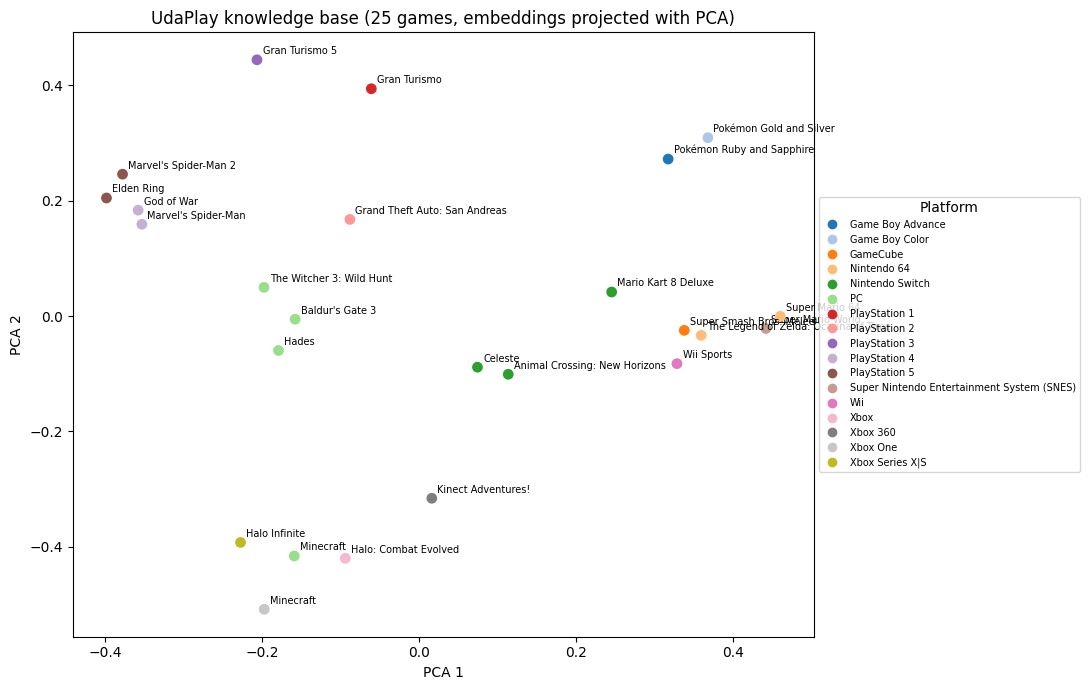

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

kb = collection.get(include=["embeddings", "metadatas"])
kb_vectors = np.array(kb["embeddings"])
kb_meta = kb["metadatas"]
pca = PCA(n_components=2).fit(kb_vectors)
kb_xy = pca.transform(kb_vectors)

platforms = sorted({m["Platform"] for m in kb_meta})
colors = {p: plt.cm.tab20(i % 20) for i, p in enumerate(platforms)}


def draw_map(ax, highlight=None, query_xy=None):
    for (x, y), m in zip(kb_xy, kb_meta):
        hit = highlight is not None and m["Name"] in highlight
        ax.scatter(x, y, color=colors[m["Platform"]], s=140 if hit else 60,
                   edgecolor="black" if hit else "none", linewidth=1.5, zorder=3)
        ax.annotate(m["Name"], (x, y), fontsize=7, xytext=(4, 4), textcoords="offset points")
    if query_xy is not None:
        ax.scatter(*query_xy, marker="*", s=300, color="red", zorder=4, label="query")
        for name in highlight or []:
            i = next(k for k, m in enumerate(kb_meta) if m["Name"] == name)
            ax.plot([query_xy[0], kb_xy[i][0]], [query_xy[1], kb_xy[i][1]], "r--", alpha=0.5, zorder=2)
        ax.legend(loc="best")
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")


fig, ax = plt.subplots(figsize=(11, 7))
draw_map(ax)
ax.set_title(f"UdaPlay knowledge base ({len(kb_meta)} games, embeddings projected with PCA)")
ax.legend(handles=[plt.Line2D([], [], marker="o", ls="", color=colors[p], label=p) for p in platforms],
          fontsize=7, loc="center left", bbox_to_anchor=(1, 0.5), title="Platform")
plt.tight_layout()
plt.show()

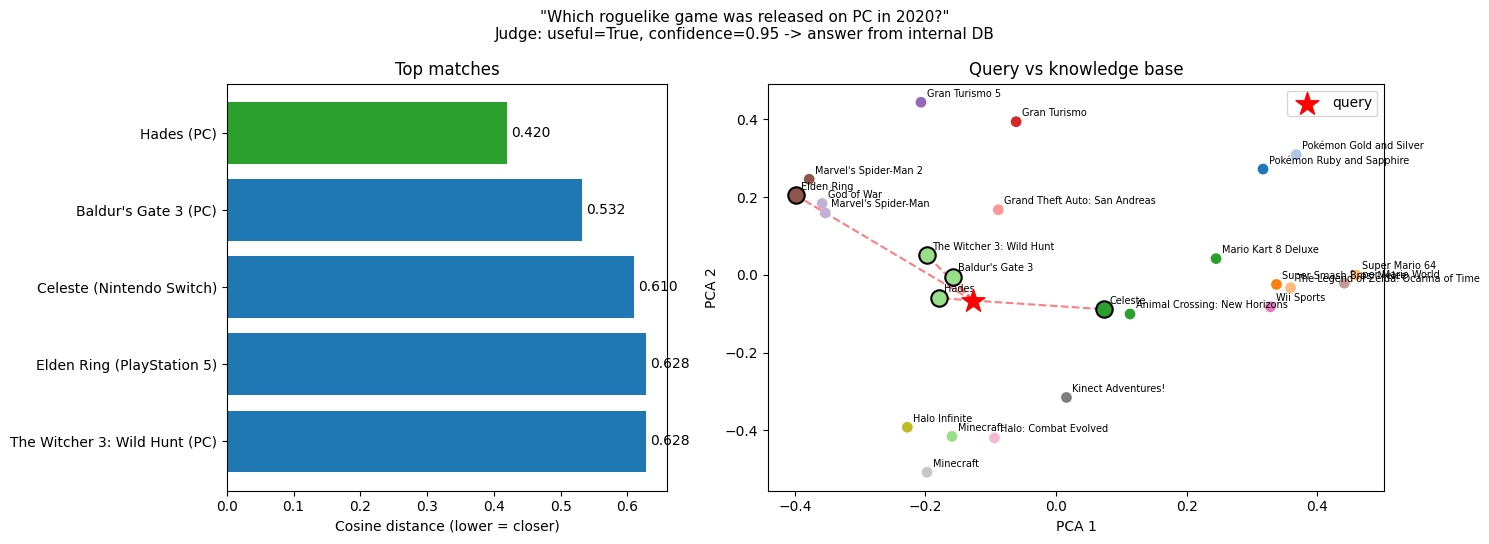

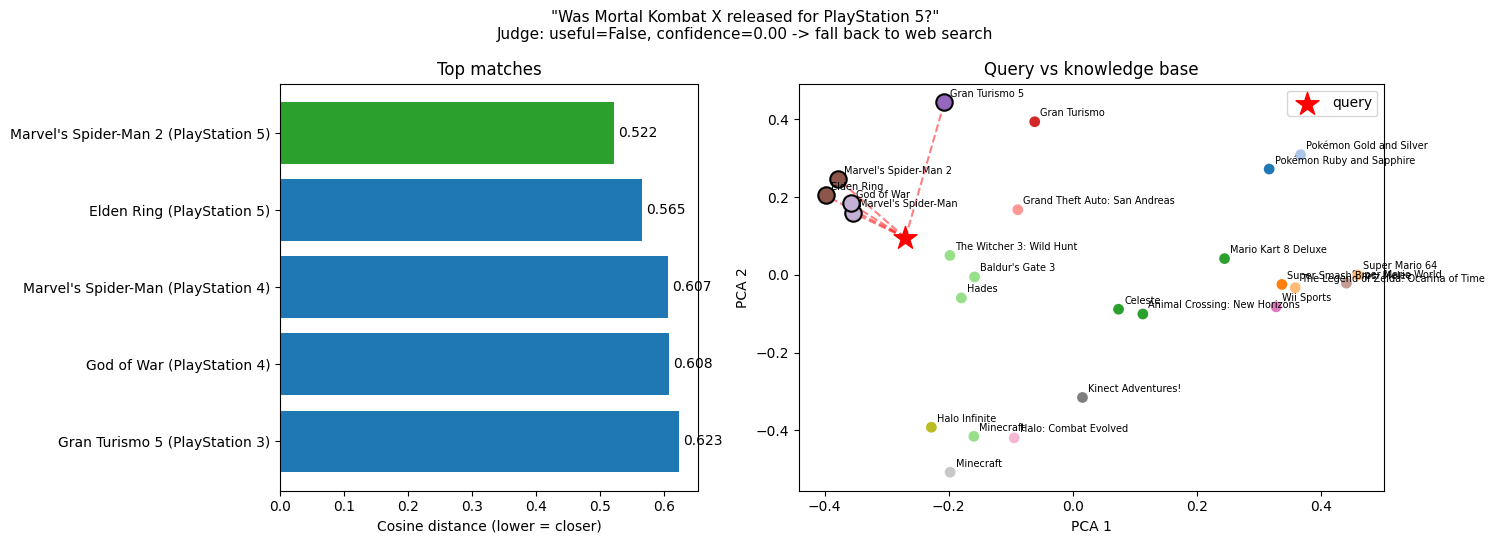

In [17]:
def retrieval_dashboard(question: str, k: int = 5):
    res = collection.query(query_texts=[question], n_results=k, include=["metadatas", "distances", "embeddings"])
    metas, dists = res["metadatas"][0], res["distances"][0]
    names = [f"{m['Name']} ({m['Platform']})" for m in metas]
    verdict = evaluate_retrieval(question, [
        {"Platform": m["Platform"], "Name": m["Name"], "YearOfRelease": m["YearOfRelease"],
         "Description": m["Description"], "distance": round(d, 3)} for m, d in zip(metas, dists)
    ])
    query_xy = pca.transform(np.array(res["query_embeddings"]) if res.get("query_embeddings") is not None
                             else np.array(embedding_fn([question])))[0]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={"width_ratios": [1, 1.4]})
    bars = ax1.barh(names[::-1], dists[::-1], color=["tab:green" if d == min(dists) else "tab:blue" for d in dists[::-1]])
    ax1.bar_label(bars, fmt="%.3f", padding=3)
    ax1.set_xlabel("Cosine distance (lower = closer)")
    ax1.set_title("Top matches")
    draw_map(ax2, highlight={m["Name"] for m in metas}, query_xy=query_xy)
    ax2.set_title("Query vs knowledge base")

    action = "answer from internal DB" if verdict["useful"] else "fall back to web search"
    fig.suptitle(f'"{question}"\nJudge: useful={verdict["useful"]}, confidence={verdict["confidence"]:.2f} -> {action}',
                 fontsize=11)
    plt.tight_layout()
    plt.show()


retrieval_dashboard("Which roguelike game was released on PC in 2020?")
retrieval_dashboard("Was Mortal Kombat X released for PlayStation 5?")